In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
df=pd.read_csv('cleaned_dataset.csv', encoding='latin1')

# Detailed Transformation Scenarios (15–20)

## 1. Exceedance flags vs daily/hourly standards

In [42]:
df['PM2_5_flag_daily']=df['PM2_5']>df['Pollutant_standard_daily']
df['PM2_5_flag_hourly']=df['PM2_5']>df['Pollutant_standard_hourly']

In [43]:
df['PM2_5_flag_daily'].head(5)

0    True
1    True
2    True
3    True
4    True
Name: PM2_5_flag_daily, dtype: bool

In [44]:
df['PM2_5_flag_daily'].unique()

array([ True, False])

In [45]:
ans={True:1,False:0}
df['PM2_5_flag_daily']=df['PM2_5_flag_daily'].map(ans)

In [46]:
df['PM2_5_flag_daily'].unique()

array([1, 0], dtype=int64)

In [47]:
df['PM2_5_flag_daily']

0        1
1        1
2        1
3        1
4        1
        ..
14574    1
14575    1
14576    1
14577    1
14578    1
Name: PM2_5_flag_daily, Length: 14579, dtype: int64

In [48]:
df['PM2_5_flag_hourly']=df['PM2_5_flag_hourly'].map(ans)

In [49]:
df['SO2_flag_daily']=df['SO2']>df['Pollutant_standard_daily']
df['SO2_flag_hourly']=df['SO2']>df['Pollutant_standard_hourly']


In [50]:
df['SO2_flag_daily'].head(5)

0     True
1     True
2    False
3     True
4     True
Name: SO2_flag_daily, dtype: bool

In [51]:
df['SO2_flag_daily'].unique()

array([ True, False])

In [52]:
df['SO2_flag_daily']=df['SO2_flag_daily'].map(ans)

In [53]:
df['SO2_flag_daily'].unique()

array([1, 0], dtype=int64)

In [54]:
df['SO2_flag_daily']

0        1
1        1
2        0
3        1
4        1
        ..
14574    1
14575    0
14576    1
14577    0
14578    1
Name: SO2_flag_daily, Length: 14579, dtype: int64

In [55]:
df['SO2_flag_hourly']=df['SO2_flag_hourly'].map(ans)

In [56]:
df['NOx_flag_daily']=df['NOx']>df['Pollutant_standard_daily']
df['NOx_flag_hourly']=df['NOx']>df['Pollutant_standard_hourly']


In [57]:
df['NOx_flag_daily'].head(5)

0    False
1     True
2    False
3     True
4     True
Name: NOx_flag_daily, dtype: bool

In [58]:
df['NOx_flag_daily'].unique()

array([False,  True])

In [59]:
df['NOx_flag_daily']=df['NOx_flag_daily'].map(ans)

In [60]:
df['NOx_flag_daily'].unique()

array([0, 1], dtype=int64)

In [61]:
df['NOx_flag_daily']

0        0
1        1
2        0
3        1
4        1
        ..
14574    0
14575    1
14576    1
14577    1
14578    1
Name: NOx_flag_daily, Length: 14579, dtype: int64

In [62]:
df['NOx_flag_hourly']=df['NOx_flag_hourly'].map(ans)

In [63]:
df.loc[0:10,['PM2_5','SO2','NOx','Pollutant_standard_daily','PM2_5_flag_daily','SO2_flag_daily','NOx_flag_daily','Pollutant_standard_hourly','PM2_5_flag_hourly','SO2_flag_hourly','NOx_flag_hourly']]

,PM2_5,SO2,NOx,Pollutant_standard_daily,PM2_5_flag_daily,SO2_flag_daily,NOx_flag_daily,Pollutant_standard_hourly,PM2_5_flag_hourly,SO2_flag_hourly,NOx_flag_hourly
0,157.84,50.28,26.06,35.6,1,1,0,91.3,1,0,0
1,83870.00,29840.00,35490.00,56.9,1,1,1,66.5,1,1,1
2,155.72,18.32,50.14,64.9,1,0,0,145.8,1,0,0
3,153280.00,62150.00,28010.00,40.3,1,1,1,107.4,1,1,1
4,71150.00,11060.00,122410.00,46.3,1,1,1,176.4,1,1,1
5,279.26,20.39,112.83,28.8,1,0,1,76.7,1,0,1
6,59.58,30.52,69.09,80.8,0,0,0,57.3,1,0,1
7,152.31,15.26,82.44,99.8,1,0,0,55.0,1,0,1
8,115640.00,13250.00,38920.00,67.4,1,1,1,133.7,1,1,1
9,117070.00,44240.00,35770.00,91.0,1,1,1,67.5,1,1,1


## 2. Pollutant AQI sub‑index computation and overall AQI

In [64]:
PM2_5_limit=60

SO2_limit=80

NOx_limit=80

In [65]:
df['PM2_5_SubIndex']=(df['PM2_5']/60) * 100
df['SO2_SubIndex']=(df['SO2']/80) * 100
df['NOx_SubIndex']=(df['NOx']/80) * 100

In [66]:
df['Overall_AQI']=df[
    ['PM2_5_SubIndex','SO2_SubIndex','NOx_SubIndex']
].max(axis=1)

In [67]:
df.loc[0:11,['PM2_5','SO2','NOx','PM2_5_SubIndex','SO2_SubIndex','NOx_SubIndex','Overall_AQI']]

,PM2_5,SO2,NOx,PM2_5_SubIndex,SO2_SubIndex,NOx_SubIndex,Overall_AQI
0,157.84,50.28,26.06,263.066667,62.8500,32.5750,263.066667
1,83870.00,29840.00,35490.00,139783.333333,37300.0000,44362.5000,139783.333333
2,155.72,18.32,50.14,259.533333,22.9000,62.6750,259.533333
3,153280.00,62150.00,28010.00,255466.666667,77687.5000,35012.5000,255466.666667
4,71150.00,11060.00,122410.00,118583.333333,13825.0000,153012.5000,153012.500000
5,279.26,20.39,112.83,465.433333,25.4875,141.0375,465.433333
6,59.58,30.52,69.09,99.300000,38.1500,86.3625,99.300000
7,152.31,15.26,82.44,253.850000,19.0750,103.0500,253.850000
8,115640.00,13250.00,38920.00,192733.333333,16562.5000,48650.0000,192733.333333
9,117070.00,44240.00,35770.00,195116.666667,55300.0000,44712.5000,195116.666667


## 3. Emission load (kg/day) from concentration and flow

In [68]:
df["Flow_Rate"] = 1500

df["PM2_5_Emission_Load"] = (df["PM2_5"] * df["Flow_Rate"] * 24) / 1000
df["SO2_Emission_Load"] = (df["SO2"] * df["Flow_Rate"] * 24) / 1000
df["NOx_Emission_Load"] = (df["NOx"] * df["Flow_Rate"] * 24) / 1000

In [69]:
print(df[["PM2_5", "Flow_Rate", "PM2_5_Emission_Load"]].head())

       PM2_5  Flow_Rate  PM2_5_Emission_Load
0     157.84       1500              5682.24
1   83870.00       1500           3019320.00
2     155.72       1500              5605.92
3  153280.00       1500           5518080.00
4   71150.00       1500           2561400.00


In [70]:
print(df[["SO2", "Flow_Rate", "SO2_Emission_Load"]].head())

        SO2  Flow_Rate  SO2_Emission_Load
0     50.28       1500            1810.08
1  29840.00       1500         1074240.00
2     18.32       1500             659.52
3  62150.00       1500         2237400.00
4  11060.00       1500          398160.00


In [71]:
print(df[["NOx", "Flow_Rate", "NOx_Emission_Load"]].head())

         NOx  Flow_Rate  NOx_Emission_Load
0      26.06       1500             938.16
1   35490.00       1500         1277640.00
2      50.14       1500            1805.04
3   28010.00       1500         1008360.00
4  122410.00       1500         4406760.00


## 4. Rolling 24‑hour averages and percentiles

In [72]:
df["TS"] = pd.to_datetime(df["TS"])
df = df.sort_values(["Plant_ID", "TS"]).reset_index(drop=True)

In [73]:
df["PM2_5_Rolling_Avg"] = (df.groupby("Plant_ID")["PM2_5"].rolling(window=24).mean().reset_index(level=0, drop=True)) 
df["PM2_5_Rolling_Avg"] = df["PM2_5_Rolling_Avg"].fillna(df["PM2_5"])

df["SO2_Rolling_Avg"] = (df.groupby("Plant_ID")["SO2"].rolling(window=24).mean().reset_index(level=0, drop=True))
df["SO2_Rolling_Avg"] = df["SO2_Rolling_Avg"].fillna(df["SO2"])

df["NOx_Rolling_Avg"] = (df.groupby("Plant_ID")["NOx"].rolling(window=24).mean().reset_index(level=0, drop=True))
df["NOx_Rolling_Avg"] = df["NOx_Rolling_Avg"].fillna(df["NOx"])

In [74]:
df["PM2_5_25th_Percentile"] = df["PM2_5"].quantile(0.25)
df["PM2_5_50th_Percentile"] = df["PM2_5"].quantile(0.50)
df["PM2_5_75th_Percentile"] = df["PM2_5"].quantile(0.75)

df["SO2_25th_Percentile"] = df["SO2"].quantile(0.25)
df["SO2_50th_Percentile"] = df["SO2"].quantile(0.50)  
df["SO2_75th_Percentile"] = df["SO2"].quantile(0.75)

df["NOx_25th_Percentile"] = df["NOx"].quantile(0.25)
df["NOx_50th_Percentile"] = df["NOx"].quantile(0.50)
df["NOx_75th_Percentile"] = df["NOx"].quantile(0.75)

In [75]:
df["PM2_5_75th_Percentile"].head(40)

0     89920.0
1     89920.0
2     89920.0
3     89920.0
4     89920.0
5     89920.0
6     89920.0
7     89920.0
8     89920.0
9     89920.0
10    89920.0
11    89920.0
12    89920.0
13    89920.0
14    89920.0
15    89920.0
16    89920.0
17    89920.0
18    89920.0
19    89920.0
20    89920.0
21    89920.0
22    89920.0
23    89920.0
24    89920.0
25    89920.0
26    89920.0
27    89920.0
28    89920.0
29    89920.0
30    89920.0
31    89920.0
32    89920.0
33    89920.0
34    89920.0
35    89920.0
36    89920.0
37    89920.0
38    89920.0
39    89920.0
Name: PM2_5_75th_Percentile, dtype: float64

In [76]:
print(df[["Plant_ID","TS","PM2_5","PM2_5_Rolling_Avg","PM2_5_25th_Percentile","PM2_5_50th_Percentile","PM2_5_75th_Percentile"]].head(30))

   Plant_ID                  TS      PM2_5  PM2_5_Rolling_Avg  \
0     PL-01 2026-03-01 06:18:00     157.84         157.840000   
1     PL-01 2026-03-01 11:59:00   83870.00       83870.000000   
2     PL-01 2026-03-01 15:30:00     155.72         155.720000   
3     PL-01 2026-03-01 15:35:00  153280.00      153280.000000   
4     PL-01 2026-03-01 15:54:00   71150.00       71150.000000   
5     PL-01 2026-03-01 16:25:00     279.26         279.260000   
6     PL-01 2026-03-01 18:20:00      59.58          59.580000   
7     PL-01 2026-03-01 19:08:00     152.31         152.310000   
8     PL-01 2026-03-01 20:13:00  115640.00      115640.000000   
9     PL-01 2026-03-01 21:42:00  117070.00      117070.000000   
10    PL-01 2026-03-01 22:19:00  125570.00      125570.000000   
11    PL-01 2026-03-02 00:38:00   77160.00       77160.000000   
12    PL-01 2026-03-02 00:39:00      28.50          28.500000   
13    PL-01 2026-03-02 01:00:00      37.91          37.910000   
14    PL-01 2026-03-02 01

In [77]:
print(df[["Plant_ID","TS","SO2","SO2_Rolling_Avg","SO2_25th_Percentile","SO2_50th_Percentile","SO2_75th_Percentile"]].head(30))

   Plant_ID                  TS       SO2  SO2_Rolling_Avg  \
0     PL-01 2026-03-01 06:18:00     50.28        50.280000   
1     PL-01 2026-03-01 11:59:00  29840.00     29840.000000   
2     PL-01 2026-03-01 15:30:00     18.32        18.320000   
3     PL-01 2026-03-01 15:35:00  62150.00     62150.000000   
4     PL-01 2026-03-01 15:54:00  11060.00     11060.000000   
5     PL-01 2026-03-01 16:25:00     20.39        20.390000   
6     PL-01 2026-03-01 18:20:00     30.52        30.520000   
7     PL-01 2026-03-01 19:08:00     15.26        15.260000   
8     PL-01 2026-03-01 20:13:00  13250.00     13250.000000   
9     PL-01 2026-03-01 21:42:00  44240.00     44240.000000   
10    PL-01 2026-03-01 22:19:00  29540.00     29540.000000   
11    PL-01 2026-03-02 00:38:00  68040.00     68040.000000   
12    PL-01 2026-03-02 00:39:00     37.31        37.310000   
13    PL-01 2026-03-02 01:00:00     19.24        19.240000   
14    PL-01 2026-03-02 01:22:00     20.45        20.450000   
15    PL

In [78]:
print(df[["Plant_ID","TS","NOx","NOx_Rolling_Avg","NOx_25th_Percentile","NOx_50th_Percentile","NOx_75th_Percentile"]].head(30))

   Plant_ID                  TS        NOx  NOx_Rolling_Avg  \
0     PL-01 2026-03-01 06:18:00      26.06        26.060000   
1     PL-01 2026-03-01 11:59:00   35490.00     35490.000000   
2     PL-01 2026-03-01 15:30:00      50.14        50.140000   
3     PL-01 2026-03-01 15:35:00   28010.00     28010.000000   
4     PL-01 2026-03-01 15:54:00  122410.00    122410.000000   
5     PL-01 2026-03-01 16:25:00     112.83       112.830000   
6     PL-01 2026-03-01 18:20:00      69.09        69.090000   
7     PL-01 2026-03-01 19:08:00      82.44        82.440000   
8     PL-01 2026-03-01 20:13:00   38920.00     38920.000000   
9     PL-01 2026-03-01 21:42:00   35770.00     35770.000000   
10    PL-01 2026-03-01 22:19:00   98540.00     98540.000000   
11    PL-01 2026-03-02 00:38:00   54790.00     54790.000000   
12    PL-01 2026-03-02 00:39:00      45.66        45.660000   
13    PL-01 2026-03-02 01:00:00      69.05        69.050000   
14    PL-01 2026-03-02 01:22:00      50.05        50.05

## 5. Source contribution indicators (wind‑weighted).

In [79]:
df['Wind_Weight_PM2_5']=(df['Wind_speed_m_s']*df['PM2_5']).round(2)
df['Wind_Weight_SO2']=(df['Wind_speed_m_s']*df['SO2']).round(2)
df['Wind_Weight_NOx']=(df['Wind_speed_m_s']*df['NOx']).round(2)

In [80]:
df.loc[1:10,['PM2_5','Wind_Weight_PM2_5','SO2','Wind_Weight_SO2','NOx','Wind_Weight_NOx']]

,PM2_5,Wind_Weight_PM2_5,SO2,Wind_Weight_SO2,NOx,Wind_Weight_NOx
1,83870.00,410124.30,29840.00,145917.60,35490.00,173546.10
2,155.72,431.34,18.32,50.75,50.14,138.89
3,153280.00,1511340.80,62150.00,612799.00,28010.00,276178.60
4,71150.00,919969.50,11060.00,143005.80,122410.00,1582761.30
5,279.26,994.17,20.39,72.59,112.83,401.67
6,59.58,477.83,30.52,244.77,69.09,554.10
7,152.31,2238.96,15.26,224.32,82.44,1211.87
8,115640.00,1209594.40,13250.00,138595.00,38920.00,407103.20
9,117070.00,648567.80,44240.00,245089.60,35770.00,198165.80
10,125570.00,614037.30,29540.00,144450.60,98540.00,481860.60


## 6. Compliance rate per plant/month.

In [81]:
df[["Plant_ID", "TS", "Compliance_Status"]].head()

,Plant_ID,TS,Compliance_Status
0,PL-01,2026-03-01 06:18:00,Exceeded
1,PL-01,2026-03-01 11:59:00,Exceeded
2,PL-01,2026-03-01 15:30:00,Exceeded
3,PL-01,2026-03-01 15:35:00,Exceeded
4,PL-01,2026-03-01 15:54:00,Exceeded


In [82]:
df["Month"] = df["TS"].dt.to_period("M")

In [83]:
compliance = (
    df.groupby(["Plant_ID", "Month"])["Compliance_Status"]
      .apply(lambda x: (x == "Within Limit").mean() * 100)
      .reset_index(name="Compliance_Rate (%)")
)

In [84]:
compliance["Compliance_Rate (%)"] = compliance["Compliance_Rate (%)"].round(2)

In [85]:
compliance.head()

,Plant_ID,Month,Compliance_Rate (%)
0,PL-01,2026-03,34.11
1,PL-01,2026-04,50.00
2,PL-02,2026-03,29.89
3,PL-02,2026-04,20.00
4,PL-03,2026-03,30.99


## 7. Episode detection (high pollution events).

In [86]:
df['PM2_5_Status'].unique()

array(['Exceeded', 'Within Limit'], dtype=object)

In [87]:
df['SO2_Status'].unique()

array(['Within Limit', 'Exceeded'], dtype=object)

In [88]:
df['NOx_Status'].unique()

array(['Within Limit', 'Exceeded'], dtype=object)

In [89]:
df['Pollution_Event']='Within Limit'
df['Pollution_Event']=(df['PM2_5_Status']=='Exceeded') | (df['SO2_Status']=='Exceeded') | (df['NOx_Status']=='Exceeded')

In [90]:
df['Pollution_Event'].unique()

array([ True, False])

In [91]:
df['Pollution_Event']=df['Pollution_Event'].replace(True,'High_Pollution_Event')
df['Pollution_Event']=df['Pollution_Event'].replace(False,'Within Limit')

In [92]:
df['Pollution_Event']

0        High_Pollution_Event
1        High_Pollution_Event
2        High_Pollution_Event
3        High_Pollution_Event
4        High_Pollution_Event
                 ...         
14574    High_Pollution_Event
14575    High_Pollution_Event
14576    High_Pollution_Event
14577            Within Limit
14578    High_Pollution_Event
Name: Pollution_Event, Length: 14579, dtype: object

In [93]:
df['Pollution_Event'].value_counts()

Pollution_Event
High_Pollution_Event    9931
Within Limit            4648
Name: count, dtype: int64

## 8. Spatial interpolation grids for maps.

In [94]:
df["Grid_Lat"] = df["Latitude"].round(1)
df["Grid_Lon"] = df["Longitude"].round(1)
grid_data = (df.groupby(["Grid_Lat", "Grid_Lon"])[["PM2_5", "SO2", "NOx"]].mean().reset_index())
grid_data.rename(columns={"PM2_5": "Average_PM2_5", "SO2": "Average_SO2", "NOx": "Average_NOx"}, inplace=True)

In [95]:
print(grid_data.head(30))

    Grid_Lat  Grid_Lon  Average_PM2_5    Average_SO2   Average_NOx
0       13.1      78.0   50301.506572   15689.096545  20652.031093
1       13.3      80.3   49761.179385  148607.235989  19037.273810
2       13.3      81.7   49621.208406   13941.696919  18311.831541
3       13.5      76.0   48547.445041   13604.616503  18760.067596
4       13.6      78.5   49621.206888  147551.971367  18999.927713
5       13.9      77.0   51087.461134   14487.684699  20411.408060
6       13.9      78.6   53441.711795   16247.922953  19094.136884
7       14.2      76.6   49832.298201   15269.363585  21868.232698
8       14.2      77.5   49613.153554  279974.054072  20718.781021
9       14.2      77.6   51337.444953   13462.546346  20711.925995
10      14.3      78.5   55795.673308   14798.490734  20564.537001
11      14.4      79.6   51013.615770   13971.929288  19068.820959
12      14.7      80.6   45787.604488  153935.479529  19361.134612
13      14.9      81.7   51355.657784  151603.673953  20234.99

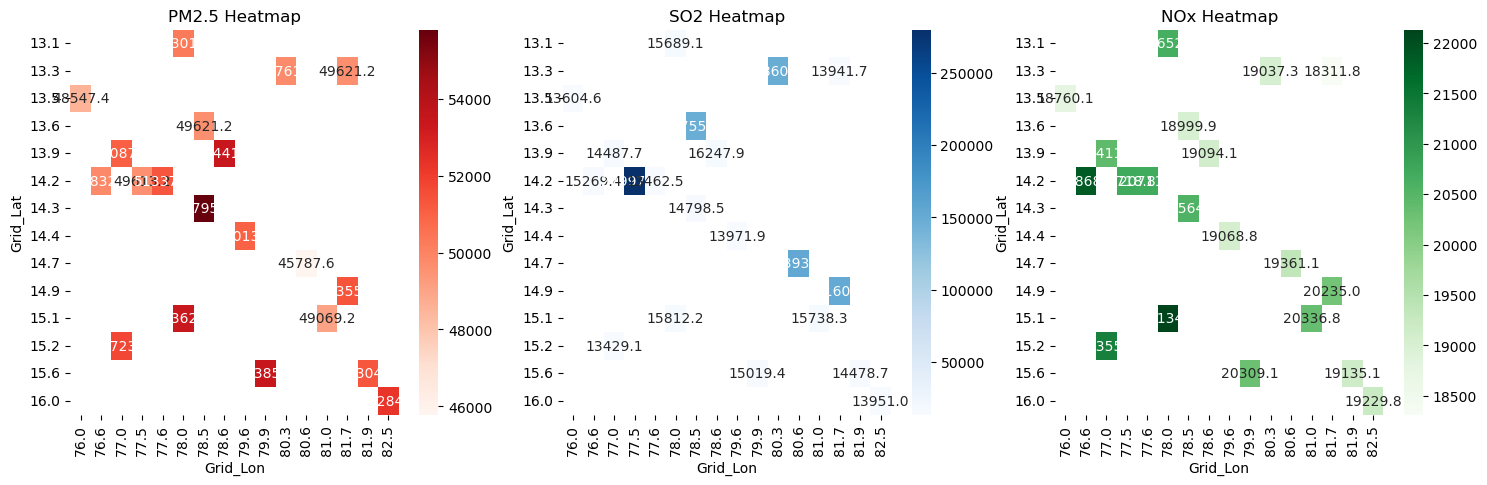

In [96]:
pm = grid_data.pivot_table(values="Average_PM2_5", index="Grid_Lat", columns="Grid_Lon", aggfunc="mean")
so2 = grid_data.pivot_table(values="Average_SO2", index="Grid_Lat", columns="Grid_Lon", aggfunc="mean")
nox = grid_data.pivot_table(values="Average_NOx", index="Grid_Lat", columns="Grid_Lon", aggfunc="mean")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(pm, annot=True, cmap="Reds", fmt=".1f", ax=axes[0])
axes[0].set_title("PM2.5 Heatmap")

sns.heatmap(so2, annot=True, cmap="Blues", fmt=".1f", ax=axes[1])
axes[1].set_title("SO2 Heatmap")

sns.heatmap(nox, annot=True, cmap="Greens", fmt=".1f", ax=axes[2])
axes[2].set_title("NOx Heatmap")

plt.show()

## 9. Health risk proxy index (PM2.5 exposure).

In [97]:
df['PM2_5'].head()

0       157.84
1     83870.00
2       155.72
3    153280.00
4     71150.00
Name: PM2_5, dtype: float64

In [98]:
df['Health_Risk_Index']=np.where(
    df['PM2_5']<=15,1,
    np.where(
        df['PM2_5']<=35,2,
    np.where(
        df['PM2_5']<=55,3,
        np.where(
                df['PM2_5']<=100,4,5
            )
        )
    )
)

In [99]:
risk_map = {
    1: "Low",
    2: "Moderate",
    3: "High",
    4: "Very High",
    5: "Hazardous"
}

In [100]:
df["Health_Risk"] = df["Health_Risk_Index"].map(risk_map)

In [101]:
df[['PM2_5','Health_Risk']]

,PM2_5,Health_Risk
0,157.84,Hazardous
1,83870.00,Hazardous
2,155.72,Hazardous
3,153280.00,Hazardous
4,71150.00,Hazardous
...,...,...
14574,136.61,Hazardous
14575,119.22,Hazardous
14576,178700.00,Hazardous
14577,73.57,Very High


In [102]:
df['Health_Risk'].value_counts()

Health_Risk
Hazardous    10591
Very High     2619
High           893
Moderate       386
Low             90
Name: count, dtype: int64

## 10. Diurnal and weekly seasonality profiles.

In [103]:
df["Hour"] = df["TS"].dt.hour
df["Day"] = df["TS"].dt.day_name()

In [104]:
hourly_profile = (df.groupby("Hour", as_index=False)[["PM2_5", "SO2", "NOx"]].mean())
weekly_profile = (df.groupby("Day", as_index=False)[["PM2_5", "SO2", "NOx"]].mean())

In [105]:
print(weekly_profile, hourly_profile)

         Day         PM2_5            SO2           NOx
0     Friday  50380.319355   13954.301712  20961.235005
1     Monday  51576.086884   56972.305823  20705.873848
2   Saturday  49851.961313  119785.926248  19537.424223
3     Sunday  50619.317363  105482.675923  19648.707870
4   Thursday  49036.734742   15136.704351  19011.998186
5    Tuesday  52023.777168   14332.819176  19925.590786
6  Wednesday  52322.716346   65376.718502  20205.022768     Hour         PM2_5            SO2           NOx
0      0  49431.076869   14389.174310  19858.659192
1      1  52717.312174   13392.805819  18366.888378
2      2  58725.977451   17441.287143  22672.532370
3      3  47412.810745  187433.903813  19553.847782
4      4  48152.658113  179396.607384  19455.511954
5      5  44395.677826   14960.156055  18267.708374
6      6  53840.719088  175432.719008  20997.299488
7      7  52510.179254   14170.739055  20264.997463
8      8  50432.013292   13716.006396  19830.252933
9      9  49793.108903  178111.7

## 11. Meteorology joins (wind, temp, RH).

In [106]:
air_quality = df[[
    "TS",
    "Plant_ID",
    "PM2_5",
    "SO2",
    "NOx",
    "Overall_AQI"
]]

In [107]:
meteorology = df[[
    "TS",
    "Wind_speed_m_s",
    "Wind_dir_deg",
    "Temp_C",
    "RH_pct"
]]

In [108]:
pd.merge(air_quality,meteorology,on='TS',how='left')

,TS,Plant_ID,PM2_5,SO2,NOx,Overall_AQI,Wind_speed_m_s,Wind_dir_deg,Temp_C,RH_pct
0,2026-03-01 06:18:00,PL-01,157.84,50.28,26.06,263.066667,12.91,161.1,39.3,56.5
1,2026-03-01 11:59:00,PL-01,83870.00,29840.00,35490.00,139783.333333,4.89,48.1,25.7,78.2
2,2026-03-01 11:59:00,PL-01,83870.00,29840.00,35490.00,139783.333333,3.65,18.8,40.1,34.6
3,2026-03-01 15:30:00,PL-01,155.72,18.32,50.14,259.533333,2.77,98.4,23.1,74.5
4,2026-03-01 15:30:00,PL-01,155.72,18.32,50.14,259.533333,3.28,195.3,21.9,74.4
...,...,...,...,...,...,...,...,...,...,...
19130,2026-04-01 00:26:00,PL-20,119.22,44.96,116.86,198.700000,6.76,279.5,20.8,32.4
19131,2026-04-01 03:02:00,PL-20,178700.00,13100.00,45850.00,297833.333333,5.56,41.8,31.9,70.1
19132,2026-04-01 04:47:00,PL-20,73.57,27.16,72.41,122.616667,9.08,276.9,31.2,20.3
19133,2026-04-01 04:47:00,PL-20,73.57,27.16,72.41,122.616667,9.16,300.8,21.4,30.6


## 12. Emission factor application for sectors.

In [109]:
df['Source_Type'].value_counts()

Source_Type
stack         8055
ambient       3558
lab           2247
inspection     719
Name: count, dtype: int64

In [110]:
var = {
    'stack':1.2,
    'ambient':0.7,
    'lab':0.5,
    'inspection':0.9
}

In [111]:
df['Emission_Factor']=df['Source_Type'].map(var)

In [112]:
df['Emission_Factor'].head()

0    0.5
1    1.2
2    0.7
3    1.2
4    0.9
Name: Emission_Factor, dtype: float64

In [113]:
df['Estimated_Emission_PM2_5']=(df['PM2_5'] * df['Emission_Factor']).round(2)
df['Estimated_Emission_SO2']=(df['SO2'] * df['Emission_Factor']).round(2)
df['Estimated_Emission_NOx']=(df['NOx'] * df['Emission_Factor']).round(2)

In [114]:
df.loc[1:10,['Estimated_Emission_PM2_5','Estimated_Emission_SO2','Estimated_Emission_NOx']]

,Estimated_Emission_PM2_5,Estimated_Emission_SO2,Estimated_Emission_NOx
1,100644.00,35808.00,42588.00
2,109.00,12.82,35.10
3,183936.00,74580.00,33612.00
4,64035.00,9954.00,110169.00
5,195.48,14.27,78.98
6,41.71,21.36,48.36
7,182.77,18.31,98.93
8,138768.00,15900.00,46704.00
9,81949.00,30968.00,25039.00
10,150684.00,35448.00,118248.00


## 13. Change‑point detection for drift alarms.

## 14. Gap‑filled vs raw comparison metrics.

## 15. Regulatory reporting tables (Stack, Ambient).

## 16. Model features for forecasting PM2.5.

## 17. Hotspot ranking by persistence and intensity.

## 18. Control measure impact evaluation (pre/post).

## 19. Compliance penalty estimation.

## 20. Open data extract with privacy safeguards.